In [195]:
import seaborn as sns
df = sns.load_dataset("titanic")

In [196]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [198]:
start_len = len(df)
without_duplicates_df = df[~ df.duplicated()]
end_len = len(without_duplicates_df)
print(start_len - end_len)

107


In [199]:
df.isna().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


In [200]:
df[['age', 'fare']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [201]:
df["sex"].value_counts(normalize=True, dropna=False)

,proportion
sex,
male,0.647587
female,0.352413


In [202]:
df["class"].value_counts(normalize=True, dropna=False)

,proportion
class,
Third,0.551066
First,0.242424
Second,0.206510


In [203]:
import matplotlib.pyplot as plt

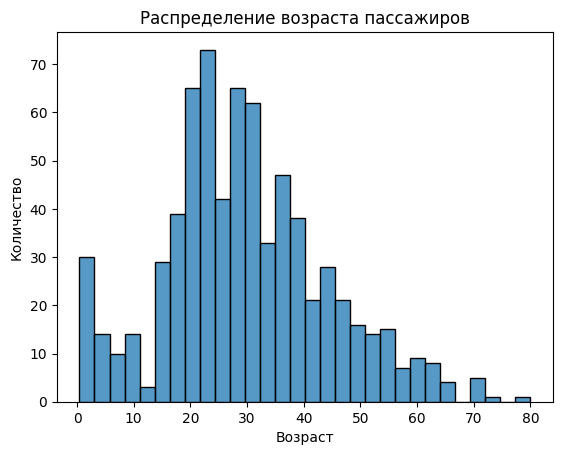

In [204]:
sns.histplot(data=df, x="age", bins=30)
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.show()

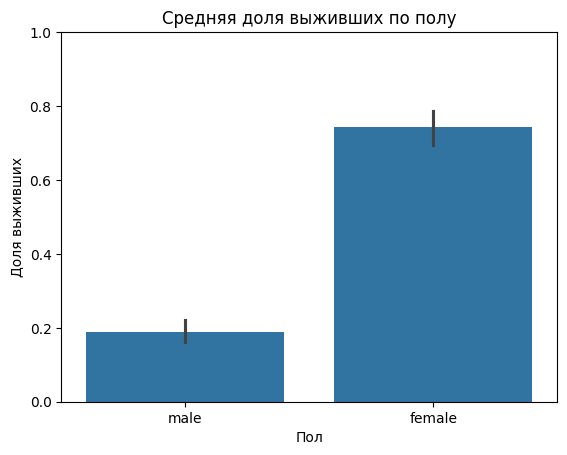

In [205]:
sns.barplot(data=df, x="sex", y="survived")
plt.title("Средняя доля выживших по полу")
plt.xlabel("Пол")
plt.ylabel("Доля выживших")
plt.ylim(0, 1)
plt.show()

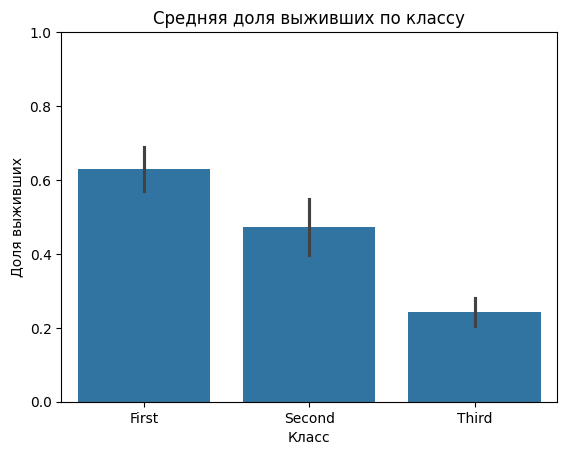

In [206]:
sns.barplot(data=df, x="class", y="survived")
plt.title("Средняя доля выживших по классу")
plt.xlabel("Класс")
plt.ylabel("Доля выживших")
plt.ylim(0, 1)
plt.show()

**Задание 2 логистическая регрессия**

In [207]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [208]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [209]:
from sklearn.model_selection import train_test_split
df = df.dropna(subset=["embarked"])

x_num = ['pclass',  'age', 'sibsp', 'parch', 'fare']
x_category = ['sex','embarked','alone']
x_columns = x_num + x_category

X = df[x_columns]
Y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [210]:
age_median = X_train["age"].median()

X_train["age"] = X_train["age"].fillna(age_median)
X_test["age"] = X_test["age"].fillna(age_median)
age_median

28.0

In [211]:
X_train["sex"] = X_train["sex"].map({"male": 1,"female": 0})

X_test["sex"] = X_test["sex"].map({"male": 1,"female": 0})

In [212]:
X_train["alone"] = X_train["alone"].map({True: 1,False: 0})

X_test["alone"] = X_test["alone"].map({True: 1,False: 0})

In [213]:
X_train["embarked_C"] = 0
X_train["embarked_Q"] = 0

for i in X_train.index:
    if X_train.loc[i, "embarked"] == "C":
        X_train.loc[i, "embarked_C"] = 1

    elif X_train.loc[i, "embarked"] == "Q":
        X_train.loc[i, "embarked_Q"] = 1

X_train = X_train.drop(columns=["embarked"])

In [214]:
X_test["embarked_C"] = 0
X_test["embarked_Q"] = 0

for i in X_test.index:
    if X_test.loc[i, "embarked"] == "C":
        X_test.loc[i, "embarked_C"] = 1

    elif X_test.loc[i, "embarked"] == "Q":
        X_test.loc[i, "embarked_Q"] = 1

X_test = X_test.drop(columns=["embarked"])

In [215]:
X_train.head()

,pclass,age,sibsp,parch,fare,sex,alone,embarked_C,embarked_Q
621,1,42.0,1,0,52.5542,1,0,0,0
481,2,28.0,0,0,0.0000,1,1,0,0
527,1,28.0,0,0,221.7792,1,1,0,0
435,1,14.0,1,2,120.0000,0,0,0,0
797,3,31.0,0,0,8.6833,0,1,0,0


In [216]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [217]:
pred1 = model.predict(X_test)
prob1 = model.predict_proba(X_test)[:, 1]
pred1

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0])

In [218]:
import numpy as np
X_train_cp = X_train.copy()
X_test_cp = X_test.copy()

X_train_cp.insert(0, "ones", 1)
X_test_cp.insert(0, "ones", 1)

X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

n = X_train_np.shape[1]

weights = np.zeros(n)

lambd = 0.001
iters = 10000


for i in range(iters):

    z = X_train_np @ weights

    y_prob = 1 / (1 + np.exp(-z))

    error = y_prob - y_train_np

    dw = (X_train_np.T @ error) / len(X_train_np)

    weights -= lambd * dw

prob2 = 1 / (1 + np.exp(-(X_test_np @ weights)))

pred2 = (prob2 >= 0.5).astype(int)

In [219]:
def metrics(pred,prob):
  tp = np.sum((pred == 1) & (y_test_np == 1))
  tn = np.sum((pred == 0) & (y_test_np == 0))
  fp = np.sum((pred == 1) & (y_test_np == 0))
  fn = np.sum((pred == 0) & (y_test_np == 1))

  accuracy = (tp + tn) / (tp + tn + fp + fn)

  precision = tp / (tp + fp)

  recall = tp / (tp + fn)
  f1 = (2 * precision * recall / (precision + recall))

  positive_prob = prob[y_test_np == 1]
  negative_prob = prob[y_test_np == 0]
  comp = positive_prob[:, None] - negative_prob[None, :]

  roc_auc = np.mean((comp > 0) + 0.5 * (comp== 0))

  print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
  print(f"accuracy:  {accuracy}")
  print(f"precision: {precision}")
  print(f"recall:    {recall}")
  print(f"f1:  {f1}")
  print(f"rocauc:   {roc_auc}")

In [220]:
metrics(pred1, prob1)
metrics(pred2,prob2)


TP: 48, TN: 98, FP: 12, FN: 20
accuracy:  0.8202247191011236
precision: 0.8
recall:    0.7058823529411765
f1:  0.7500000000000001
rocauc:   0.8656417112299465
TP: 24, TN: 105, FP: 5, FN: 44
accuracy:  0.7247191011235955
precision: 0.8275862068965517
recall:    0.35294117647058826
f1:  0.4948453608247423
rocauc:   0.8272727272727273
